In [2]:
import sqlalchemy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn

In [3]:
from sqlalchemy import create_engine
username='root'
password="verma%401234"   # @ == %40
host="127.0.0.1"
port="3306"
database="banking"
engine=create_engine(f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}")

In [4]:
# df=pd.read_sql("banking",con=engine)
df=pd.read_sql("select * from banking;",con=engine)

In [5]:
df

,ï»¿Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,IND66827,Earl Hall,82,8760,09-10-2014,Joshua Bennett,American,Accounting Assistant III,High,Gold,...,1089957.03,532867.88,657849.62,12947.31,1238859.91,1,3,3,2,4
2996,IND40556,Billy Williamson,44,32837,05-02-2009,Dennis Ruiz,European,Paralegal,Mid,Gold,...,136891.32,56581.74,93195.61,23205.69,277171.07,1,2,3,2,5
2997,IND72414,Victor Black,70,36088,29-12-2009,Joshua Ryan,American,Statistician IV,Low,Jade,...,214860.89,158726.06,35539.15,30291.81,502947.22,2,2,3,2,6
2998,IND46652,Andrew Ford,56,24871,13-02-2006,Nicholas Cunningham,European,Human Resources Assistant III,Mid,Jade,...,742630.22,404638.26,56411.33,6413.14,1538368.60,3,1,3,2,7


In [6]:
df.columns

Index(['ï»¿Client ID', 'Name', 'Age', 'Location ID', 'Joined Bank',
       'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure',
       'Loyalty Classification', 'Estimated Income', 'Superannuation Savings',
       'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans',
       'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
       'Foreign Currency Account', 'Business Lending', 'Properties Owned',
       'Risk Weighting', 'BRId', 'GenderId', 'IAId'],
      dtype='str')

In [7]:
df=df.rename(columns={'ï»¿Client ID':"Clinet ID"})

In [8]:
df.head(5)

,Clinet ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [9]:
len(df.columns)  # 25 Columns

25

In [10]:
# df["Name"].value_counts().values    # IMP FOR PLOTTING GRAPHS Y-AXIS AND X-AXIS
# df["Name"].value_counts().index

In [11]:
df.info()   # NO NULL VALUES

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Clinet ID                 3000 non-null   str    
 1   Name                      3000 non-null   str    
 2   Age                       3000 non-null   int64  
 3   Location ID               3000 non-null   int64  
 4   Joined Bank               3000 non-null   str    
 5   Banking Contact           3000 non-null   str    
 6   Nationality               3000 non-null   str    
 7   Occupation                3000 non-null   str    
 8   Fee Structure             3000 non-null   str    
 9   Loyalty Classification    3000 non-null   str    
 10  Estimated Income          3000 non-null   float64
 11  Superannuation Savings    3000 non-null   float64
 12  Amount of Credit Cards    3000 non-null   int64  
 13  Credit Card Balance       3000 non-null   float64
 14  Bank Loans         

In [12]:
df[df.duplicated()]  # no duplicate 
# df[df.duplicated()].shape[0]  # Count duplicate 
# len(df[df.duplicated()])  # Count duplicate 

,Clinet ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId


In [13]:
df.describe()

,Age,Location ID,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,12462.273017,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,12.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


### Income Category

In [14]:
def income_category(estimated_income):
    if 0<estimated_income <100000:
        return "Low"
    elif 100000<estimated_income<300000:
        return "Mid"
    else :
        return "High"

In [15]:
df['Income Category']=df["Estimated Income"].apply(income_category)

<BarContainer object of 3 artists>

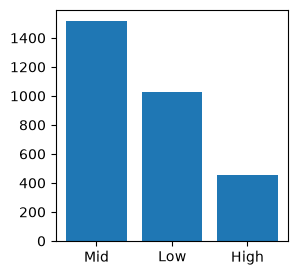

In [16]:
df['Income Category'].value_counts().values
df['Income Category'].value_counts().index
plt.figure(figsize=(3,3))
plt.bar(df['Income Category'].value_counts().index,df['Income Category'].value_counts().values)

In [17]:
categories_columns=df[['BRId', 'GenderId', 'IAId', 'Income Category', 'Properties Owned'
                         ,'Amount of Credit Cards', 'Fee Structure','Loyalty Classification',
                         'Nationality']].columns

for col in categories_columns:
    print("Values For :",col)
    display(df[col].value_counts())

Values For : BRId


BRId
3    1352
1     660
2     495
4     493
Name: count, dtype: int64

Values For : GenderId


GenderId
2    1512
1    1488
Name: count, dtype: int64

Values For : IAId


...

Fee Structure
High    1476
Mid      962
Low      562
Name: count, dtype: int64

Values For : Loyalty Classification


Loyalty Classification
Jade        1331
Silver       767
Gold         585
Platinum     317
Name: count, dtype: int64

Values For : Nationality


Nationality
European      1309
Asian          754
American       507
Australian     254
African        176
Name: count, dtype: int64

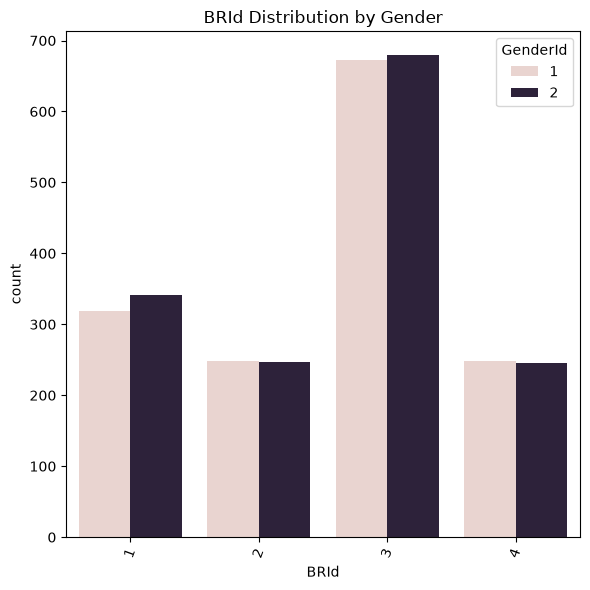

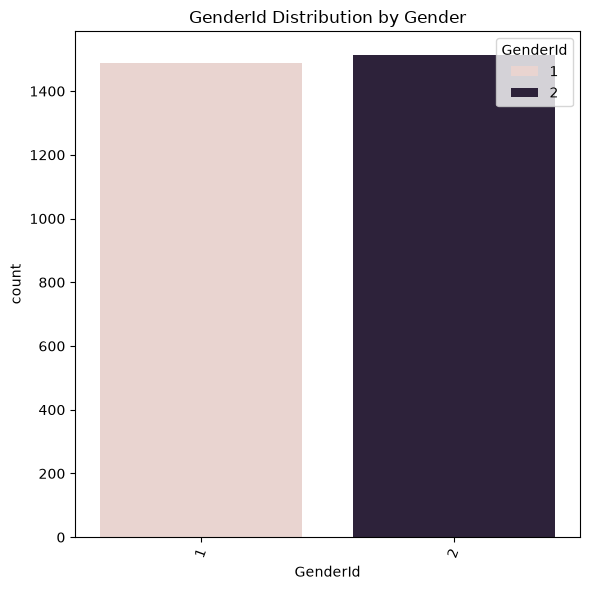

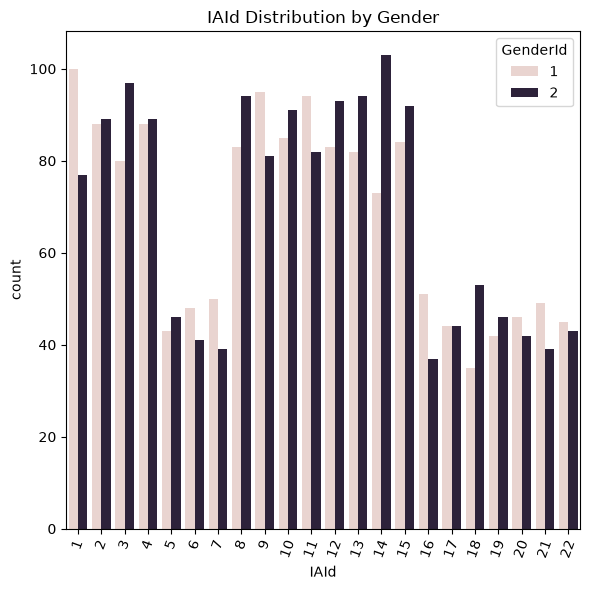

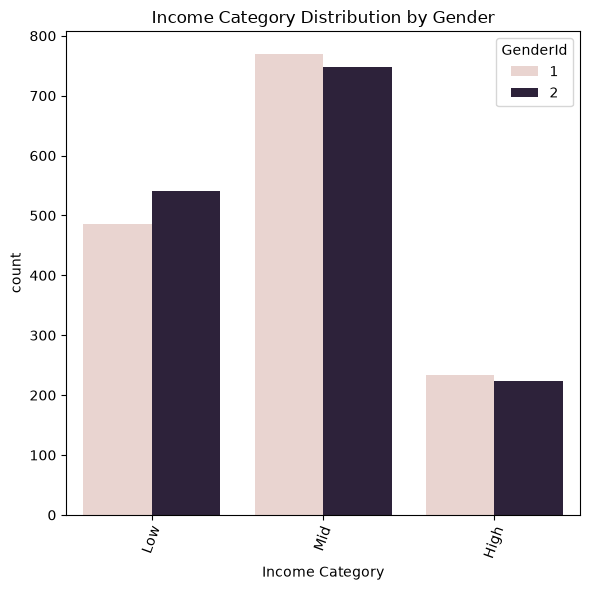

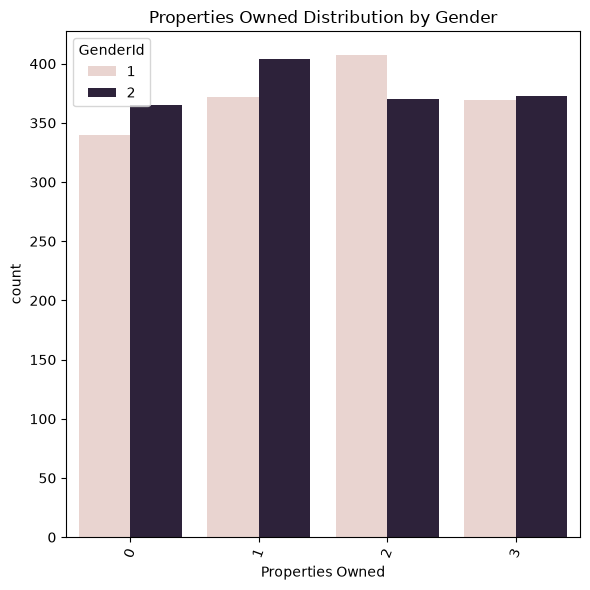

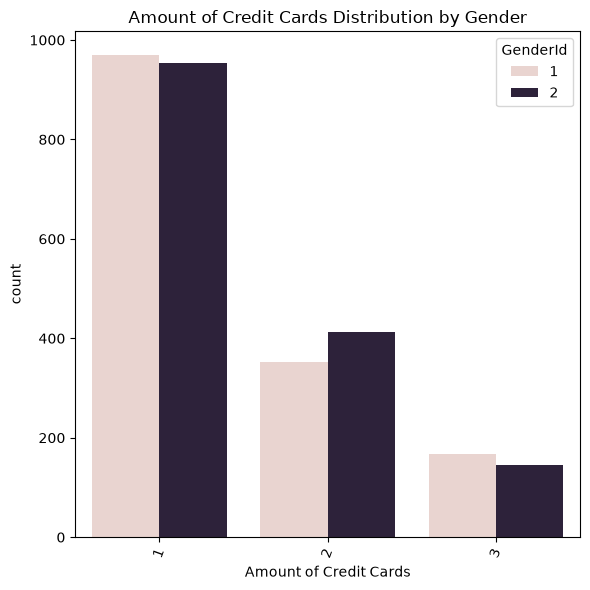

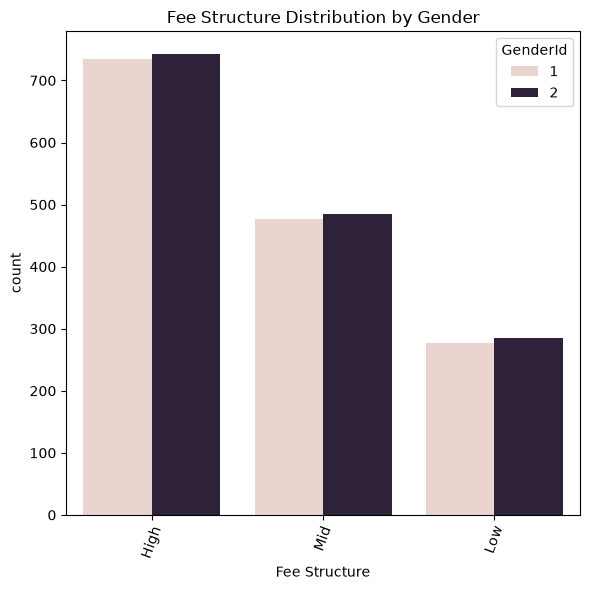

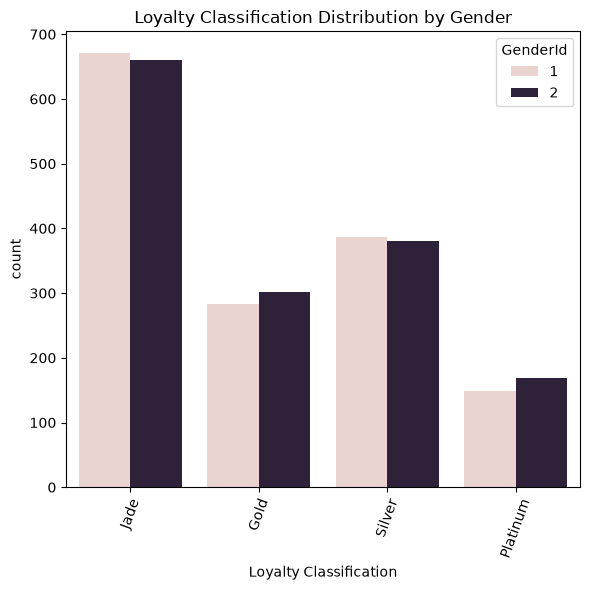

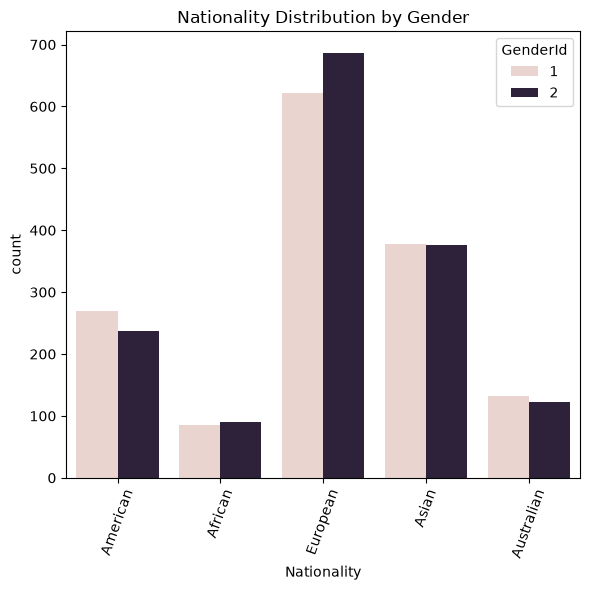

In [18]:
#  GRAPHS FOR CATEGORIES
for col in categories_columns:
    if col=="GenderID":
        continue
    else:
        plt.figure(figsize=(6,6))
        sbn.countplot(data=df, x=col, hue='GenderId')

    plt.title(f'{col} Distribution by Gender')
    plt.xticks(rotation=70)
    plt.tight_layout()
    plt.show()

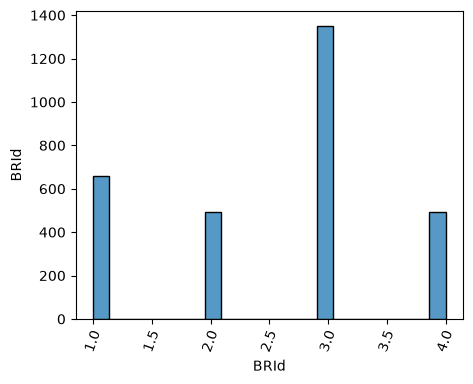

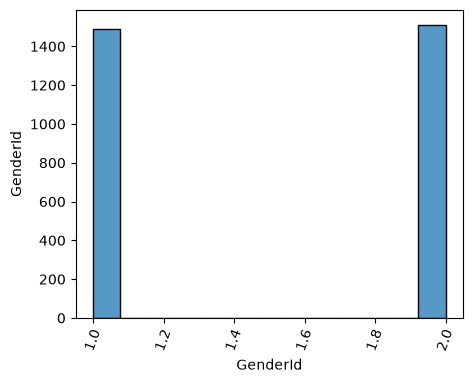

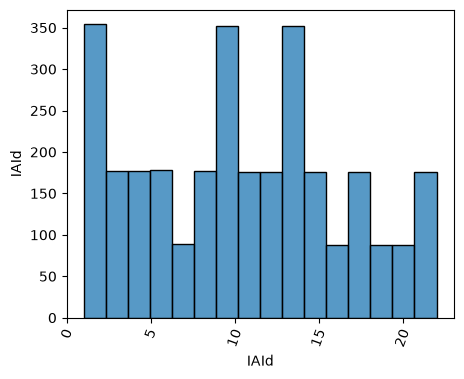

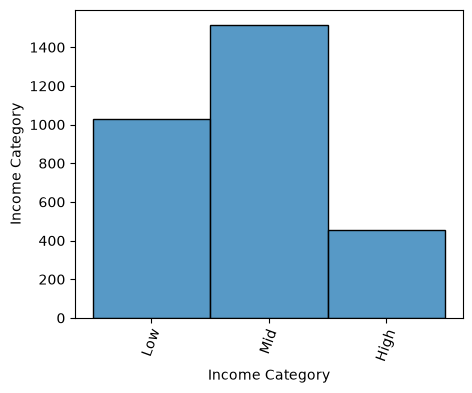

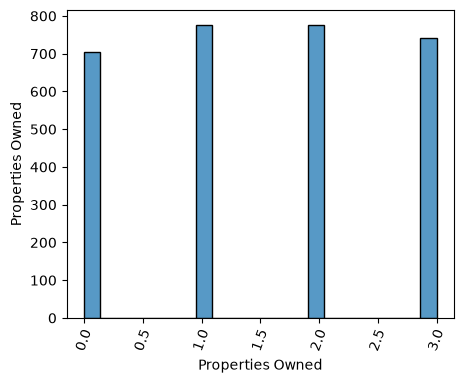

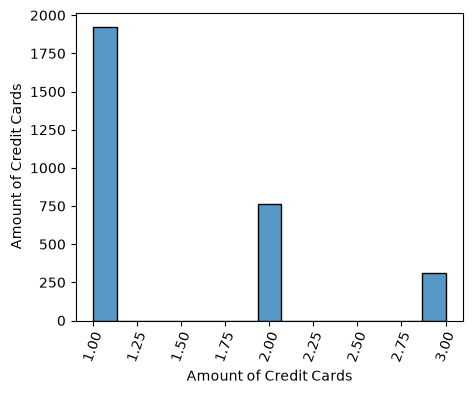

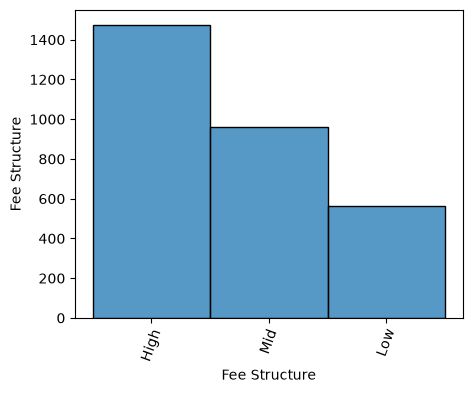

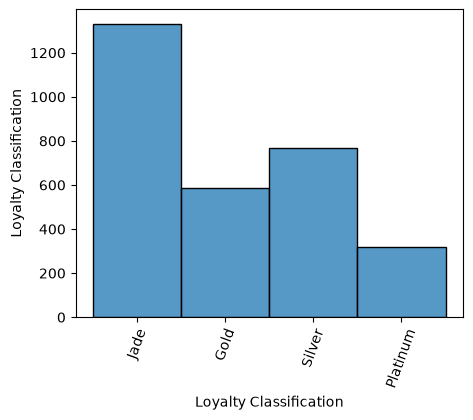

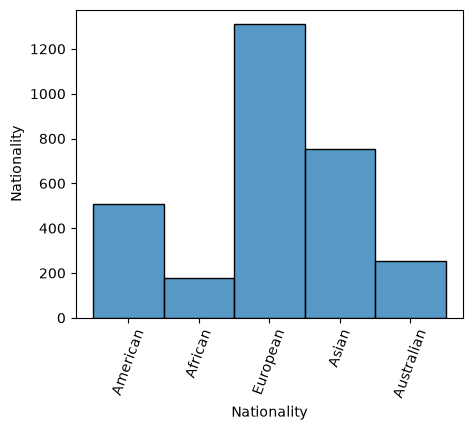

In [19]:
#  COUNT BY OCCUPATION
for col in categories_columns:
    if col=="Occupation":
        continue
    plt.figure(figsize=(5,4))
    sbn.histplot(df[col])
    plt.ylabel(col)
    plt.xticks(rotation=70)
    # plt.hist(df[col])

In [20]:
def age_category(age):
    if age <=18:
        return "Underage"
    if age <=20:
        return 'young'
    elif 20<age <=30:
        return 'young adult'
    elif 30<age <=50:
        return 'middle aged'
    else :
        return 'Senior'

In [21]:
df["Age Category"]=df['Age'].apply(age_category)

In [22]:
df.to_csv(
    "Banking_Clean.csv",
    mode="w",
        index=False
)

In [23]:
df.to_sql(
    "Banking_Clean.csv",
    con=engine,
    if_exists="replace",
    index=False
)

C:\Users\ANAND VERMA\AppData\Local\Temp\ipykernel_14520\2540809903.py:1: UserWarning: The provided table name 'Banking_Clean.csv' is not found exactly as such in the database after writing the table, possibly due to case sensitivity issues. Consider using lower case table names.
  df.to_sql(


3000